In [1]:
import cv2
from IPython import get_ipython
import matplotlib.pyplot as plt
import numpy as np
import os.path
import logging

try:
    cv2.setNumThreads(0)
except:
    pass

try:
    if __IPYTHON__:
        get_ipython().run_line_magic('load_ext', 'autoreload')
        get_ipython().run_line_magic('autoreload', '2')
except NameError:
    pass

logfile = None # Replace with a path if you want to log to a file
logger = logging.getLogger('caiman')
# Set to logging.INFO if you want much output, potentially much more output
logger.setLevel(logging.WARNING)
logfmt = logging.Formatter('%(relativeCreated)12d [%(filename)s:%(funcName)20s():%(lineno)s] [%(process)d] %(message)s')
if logfile is not None:
    handler = logging.FileHandler(logfile)
else:
    handler = logging.StreamHandler()
handler.setFormatter(logfmt)
logger.addHandler(handler)

import caiman as cm
from caiman.motion_correction import MotionCorrect, tile_and_correct, motion_correction_piecewise
from caiman.utils.utils import download_demo

# Set play_movies to False if you want to disable play of movies, e.g. for remote-hosted Jupyter environments
play_movies = True

In [2]:
fname = "/home/niels/caiman-git/data/niels_video.avi"
framerate = 5

In [ ]:
m_orig = cm.load(fname)
downsample_ratio = .2  # motion can be perceived better when downsampling in time
m_orig.resize(1, 1, downsample_ratio)
# Set play_movies to false if you want to disable play of movies, e.g. for remote-hosted Jupyter environments
if play_movies:
    m_orig.play(q_max=99.5, fr=framerate, magnification=2)   # play movie (press q to exit)

Note that here the data presented here has been downsampled in space by a factor of 2 to reduce the file size. As a result the spatial resolution is coarser here (around 2 microns per pixel). If we were operating at the original resolution, several of the parameters above, e.g., ```max_shifts, strides, overlaps, max_deviation_rigid```, could have been larger by a factor of 2.

In [4]:
max_shifts = (12, 12) #(6, 6)  # maximum allowed rigid shift in pixels (view the movie to get a sense of motion)
strides =  (96, 96) #(48, 48)  # create a new patch every x pixels for pw-rigid correction
overlaps = (48, 48) #(24, 24)  # overlap between patches (size of patch strides+overlaps)
max_deviation_rigid = 6 #3   # maximum deviation allowed for patch with respect to rigid shifts
pw_rigid = False  # flag for performing rigid or piecewise rigid motion correction
shifts_opencv = True  # flag for correcting motion using bicubic interpolation (otherwise FFT interpolation is used)
border_nan = 'copy'  # replicate values along the boundary (if True, fill in with NaN)

In [5]:
#%% start the cluster (if a cluster already exists terminate it)
if 'dview' in locals():
    cm.stop_server(dview=dview)
c, dview, n_processes = cm.cluster.setup_cluster(
    backend='multiprocessing', n_processes=None, single_thread=False)

In [6]:
# create a motion correction object
mc = MotionCorrect(fname, dview=dview, max_shifts=max_shifts,
                  strides=strides, overlaps=overlaps,
                  max_deviation_rigid=max_deviation_rigid, 
                  shifts_opencv=shifts_opencv, nonneg_movie=True,
                  border_nan=border_nan)

In [7]:
%%capture
# correct for rigid motion correction and save the file (in memory mapped form)
mc.motion_correct(save_movie=True)

100%|██████████| 1/1 [00:01<00:00,  1.74s/it]


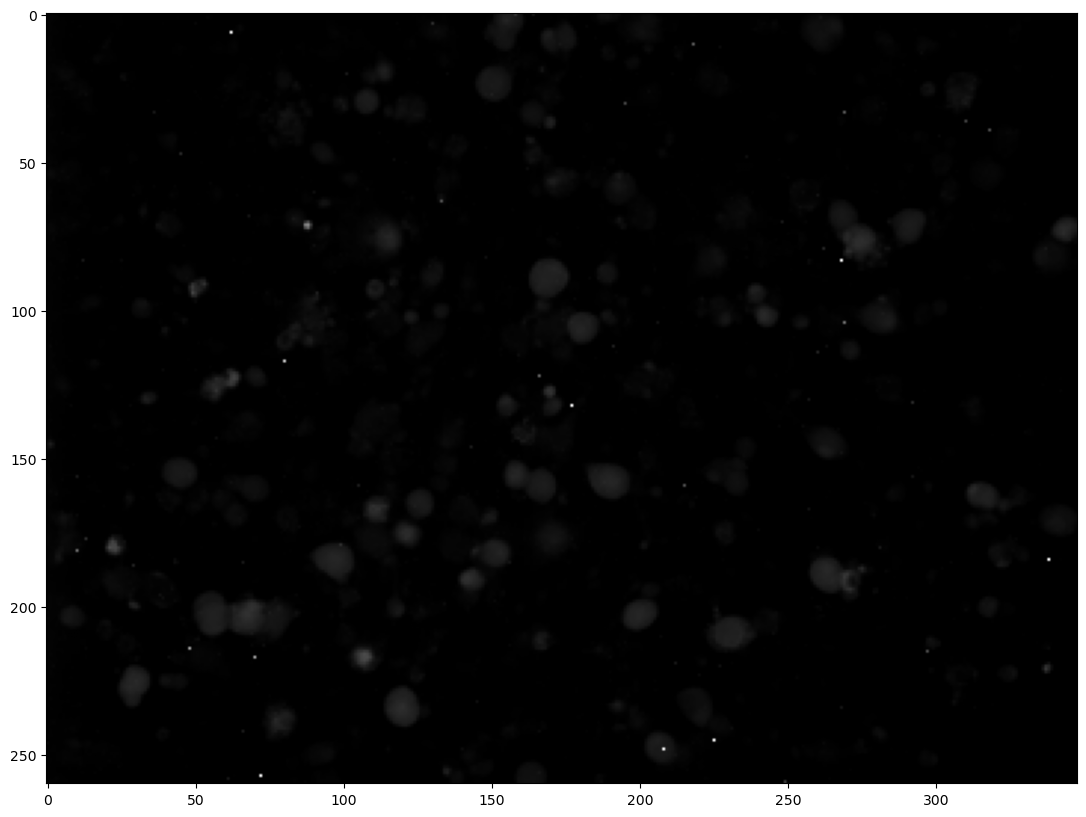

In [8]:
# load motion corrected movie
m_rig = cm.load(mc.mmap_file)
bord_px_rig = np.ceil(np.max(mc.shifts_rig)).astype(int)
#%% visualize templates
plt.figure(figsize = (20,10))
plt.imshow(mc.total_template_rig, cmap = 'gray');

#%% inspect movie
m_rig.resize(1, 1, downsample_ratio)
if play_movies:
    m_rig.play(
         q_max=99.5, fr=30, magnification=2, bord_px = 0*bord_px_rig) # press q to exit

#%% plot rigid shifts
plt.close()
plt.figure(figsize = (20,10))
plt.plot(mc.shifts_rig)
plt.legend(['x shifts','y shifts'])
plt.xlabel('frames')
plt.ylabel('pixels');

In [ ]:
%%capture
#%% motion correct piecewise rigid
mc.pw_rigid = True  # turn the flag to True for pw-rigid motion correction
mc.template = mc.mmap_file  # use the template obtained before to save in computation (optional)

mc.motion_correct(save_movie=True, template=mc.total_template_rig)
m_els = cm.load(mc.fname_tot_els)
m_els.resize(1, 1, downsample_ratio)
#if play_movies:
#    m_els.play(q_max=99.5, fr=30, magnification=2,bord_px = bord_px_rig)

h = cm.concatenate([m_orig.resize(1, 1, downsample_ratio) - mc.min_mov*mc.nonneg_movie,
                m_rig.resize(1, 1, downsample_ratio), m_els.resize(
            1, 1, downsample_ratio)], axis=2)
if play_movies:
   h.play(fr=60, q_max=99.5, magnification=2, bord_px=bord_px_rig)

#%% visualize elastic shifts
plt.close()
plt.figure(figsize = (20,10))
plt.subplot(2, 1, 1)
plt.plot(mc.x_shifts_els)
plt.ylabel('x shifts (pixels)')
plt.subplot(2, 1, 2)
plt.plot(mc.y_shifts_els)
plt.ylabel('y_shifts (pixels)')
plt.xlabel('frames')
#%% compute borders to exclude
bord_px_els = np.ceil(np.maximum(np.max(np.abs(mc.x_shifts_els)),
                                 np.max(np.abs(mc.y_shifts_els)))).astype(int)

In [10]:
cm.stop_server(dview=dview) # stop the server

In [51]:
# Shifts müssen noch applied werden auf dem originalen, nicht down-sampled Movie
from caiman.motion_correction import MotionCorrect as cmmc

# Shifts anwenden
mc_video = m_orig.cmmc.apply_shifts_movie(fname=m_orig)

# speichern
mc_video.save("niels_video_mc.avi")

AttributeError: 'movie' object has no attribute 'cmmc'